In [1]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

data_folder="../Data/"

from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, saveresults_pickle, select_rows, \
 sort_rank, compute_welch_select_regions, extract_features_from_spectra_more_bands,compute_welch, \
 plot_hist2d_selected_regions_folds, select_regions_MyCriteria, select_regions_Cohen_effect_size, \
select_regions_MyCriteria2

"""# new_row = {
#     "ROIs": [selected_regions_EEG],
#     "NROIs":[25]
#     "DataType": ["EEG"],
#     "freqs_band": [((4,8),(8,12),(12,30))],  
#     "subject": [subject_index],
#     "Classifier": ["LDA"],
#     "Performance": [training[0]],
#     "Features": ["PowerSpectra - MeanMax band"],
#     "Comments": ["-"],
#     "Region Selection": ["-"],
#     "Date": [today],
#     "Personalized_Freq_Range" = False,
# }"""


2026-05-23 13:37:04.264786: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-23 13:37:04.317612: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-23 13:37:05.459630: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


'# new_row = {\n#     "ROIs": [selected_regions_EEG],\n#     "NROIs":[25]\n#     "DataType": ["EEG"],\n#     "freqs_band": [((4,8),(8,12),(12,30))],  \n#     "subject": [subject_index],\n#     "Classifier": ["LDA"],\n#     "Performance": [training[0]],\n#     "Features": ["PowerSpectra - MeanMax band"],\n#     "Comments": ["-"],\n#     "Region Selection": ["-"],\n#     "Date": [today],\n#     "Personalized_Freq_Range" = False,\n# }'

# Perform Selections

## MyCriteria - Based on MaxDiff Rest-MI
- I am "averaging" (selecting) on frequency bins
- I am averaging among trials

This is why MyCriteria is more robust with respect to Multi T-Test on whole Power Spectra 


In [5]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
    dizio[f"ROIs_All_trials"] = []


    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch_select_regions(data_2_MI, data_2_Rest, sfreq, important_regions=[], select_regions=False,
                                                        kargs_welch={"fmin":8, "fmax":30})

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx
   
                                                            

            regions_selected = select_regions_MyCriteria(wpsdMI=WMI[selected_idx[np.where(selected_idx>=len(WRe))]-len(WRe)],  
                                                            wpsdRest=WRe[selected_idx[np.where(selected_idx<len(WRe))]], 
                                                            important_regions=[], nbest_regions=quanteroi)
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple(regions_selected))

        ########### All Trials no folds #############
        regions_selected = select_regions_MyCriteria(wpsdMI=WMI, wpsdRest=WRe, important_regions=[], nbest_regions=quanteroi)
        dizio[f"ROIs_All_trials"].append(tuple(regions_selected))

    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MyCriteria_{DataType}_among_{n_folds}_folds_training_selected_freq_8_30_v2.pkl")




100%|██████████| 20/20 [01:26<00:00,  4.32s/it]


In [3]:
WMI.shape , WRe.shape

((82, 68, 27), (83, 68, 27))

In [7]:
import pandas as pd
filepath = "../Results/RegionSelection/Selected_regions"
pandadizio=pd.read_pickle(filepath+f"_MyCriteria_EEG_among_5_folds_training_selected_freq_8_30.pkl")
pandadizio

,Subject,ROIs_fold_1,ROIs_fold_2,ROIs_fold_3,ROIs_fold_4,ROIs_fold_5,ROIs_All_trials
0,0,"(23, 15, 14, 22, 58, 50, 42, 51, 17, 6, 59, 35...","(23, 15, 17, 51, 22, 14, 35, 50, 42, 6, 59, 58...","(23, 15, 14, 22, 50, 51, 58, 17, 42, 59, 6, 35...","(23, 15, 51, 14, 35, 17, 59, 50, 22, 58, 27, 4...","(23, 15, 14, 17, 22, 50, 35, 51, 58, 42, 6, 59...","(23, 15, 14, 22, 17, 51, 50, 58, 35, 42, 59, 6..."
1,1,"(67, 61, 43, 59, 42, 17, 26, 51, 32, 1, 27, 7,...","(67, 61, 43, 59, 1, 51, 42, 17, 26, 7, 32, 19,...","(67, 61, 43, 59, 42, 51, 32, 26, 17, 1, 50, 20...","(67, 61, 43, 59, 17, 51, 42, 32, 1, 26, 50, 20...","(67, 61, 43, 59, 51, 42, 7, 26, 32, 1, 21, 50,...","(67, 61, 43, 59, 42, 51, 17, 1, 26, 32, 7, 50,..."
2,2,"(42, 14, 43, 23, 26, 48, 22, 6, 4, 27, 50, 32,...","(23, 42, 43, 14, 27, 26, 6, 48, 4, 21, 32, 20,...","(42, 43, 14, 23, 26, 27, 6, 48, 22, 35, 10, 21...","(14, 42, 43, 26, 23, 22, 27, 48, 35, 10, 4, 34...","(42, 14, 43, 23, 26, 27, 48, 6, 21, 22, 4, 32,...","(42, 14, 43, 23, 26, 27, 48, 6, 22, 4, 21, 32,..."
3,3,"(7, 23, 22, 15, 51, 50, 33, 32, 59, 45, 6, 14,...","(7, 22, 23, 51, 50, 15, 43, 14, 32, 6, 48, 42,...","(7, 22, 51, 23, 59, 15, 50, 43, 45, 14, 32, 58...","(7, 22, 23, 15, 51, 32, 50, 48, 33, 43, 5, 45,...","(7, 22, 23, 15, 51, 33, 43, 50, 32, 56, 5, 14,...","(7, 22, 23, 15, 51, 50, 43, 32, 59, 33, 14, 45..."
4,4,"(22, 16, 58, 30, 10, 7, 12, 57, 48, 47, 44, 32...","(16, 30, 22, 7, 48, 10, 44, 12, 57, 4, 32, 56,...","(16, 22, 30, 7, 48, 10, 12, 56, 57, 4, 44, 36,...","(7, 16, 30, 22, 48, 57, 47, 4, 12, 32, 44, 10,...","(7, 16, 64, 62, 30, 49, 22, 45, 10, 44, 37, 57...","(16, 22, 30, 7, 10, 48, 57, 12, 4, 32, 44, 47,..."
5,5,"(4, 6, 7, 33, 46, 43, 27, 59, 20, 47, 23, 57, ...","(6, 40, 7, 4, 58, 27, 43, 23, 22, 12, 36, 20, ...","(4, 33, 59, 7, 20, 43, 6, 46, 40, 47, 27, 23, ...","(6, 7, 33, 38, 46, 59, 24, 4, 57, 27, 28, 23, ...","(56, 54, 4, 41, 24, 6, 39, 28, 38, 55, 11, 10,...","(6, 4, 7, 33, 46, 43, 27, 23, 59, 20, 22, 38, ..."
6,6,"(48, 36, 0, 16, 34, 54, 45, 30, 50, 44, 12, 25...","(36, 0, 48, 45, 54, 16, 24, 30, 49, 50, 34, 56...","(36, 12, 56, 0, 29, 25, 64, 48, 16, 18, 50, 54...","(36, 0, 16, 48, 30, 34, 12, 14, 50, 32, 66, 18...","(0, 16, 34, 48, 62, 14, 25, 36, 30, 58, 56, 64...","(0, 36, 48, 16, 34, 30, 12, 50, 14, 54, 25, 56..."
7,7,"(7, 59, 42, 15, 43, 6, 22, 27, 49, 57, 5, 14, ...","(7, 59, 42, 49, 43, 45, 57, 27, 32, 6, 5, 22, ...","(7, 59, 42, 15, 43, 49, 22, 27, 45, 6, 5, 57, ...","(7, 42, 15, 43, 45, 49, 27, 6, 59, 5, 32, 10, ...","(7, 42, 43, 15, 59, 27, 45, 6, 22, 49, 32, 14,...","(7, 42, 59, 43, 15, 49, 27, 6, 45, 22, 57, 5, ..."
8,8,"(15, 51, 26, 50, 0, 23, 34, 27, 22, 35, 12, 43...","(27, 51, 50, 15, 26, 35, 34, 23, 13, 17, 0, 58...","(26, 27, 15, 23, 34, 50, 51, 35, 0, 17, 22, 13...","(23, 15, 50, 51, 26, 27, 34, 17, 35, 58, 13, 2...","(26, 23, 15, 34, 51, 50, 27, 0, 22, 35, 17, 13...","(15, 26, 23, 51, 50, 27, 34, 35, 0, 22, 13, 17..."
9,9,"(65, 55, 53, 10, 11, 31, 29, 52, 18, 35, 59, 5...","(65, 55, 32, 31, 53, 59, 10, 11, 23, 51, 8, 29...","(65, 55, 53, 10, 31, 18, 11, 52, 29, 59, 30, 2...","(55, 65, 53, 10, 29, 11, 52, 59, 31, 25, 37, 5...","(65, 55, 53, 59, 10, 31, 52, 11, 29, 18, 23, 6...","(65, 55, 53, 10, 31, 11, 29, 52, 59, 18, 23, 6..."


Text(0.5, 1.0, 'fixed subject, ranking in 6 kfolds')

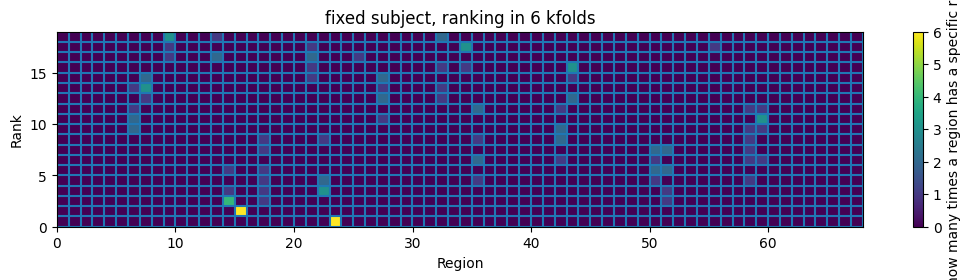

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap

subject=0
fino_a = 20

binx = np.arange(69)-0.001
biny = np.arange(fino_a)-0.001

rankings = []
for fold in range(1,len(pandadizio.keys())):
    rankings.append(list(pandadizio.iloc[subject,fold][:fino_a]))

rankings = np.array(rankings)
n_folds = rankings.shape[0]
plt.figure(figsize=(13,3.8*fino_a/30))
plt.hist2d(rankings.flatten(),np.tile(np.arange(fino_a), (n_folds,1)).flatten(),bins=(binx,biny))
#plt.hist2d(pandadizio.iloc[subject,1][:fino_a],range(fino_a),bins=(binx,biny))
plt.vlines(binx,0,fino_a)
plt.hlines(biny,0,68)
plt.colorbar(label="how many times a region has a specific rank")
plt.xlabel("Region")
plt.ylabel("Rank")
plt.title(f"fixed subject, ranking in {len(rankings)} kfolds")

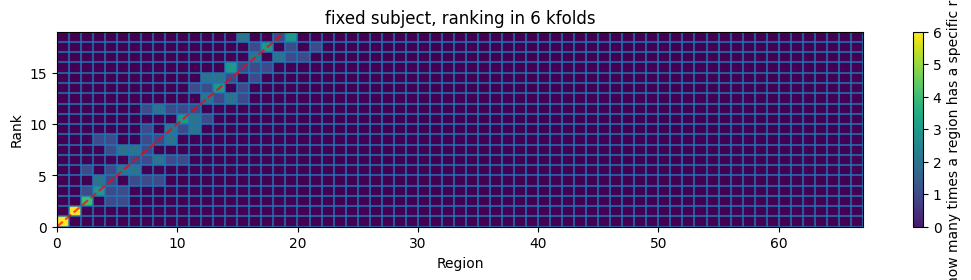

In [9]:
rankings_sorted, sorted_regions =  sort_rank(rankings)

plt.figure(figsize=(13,3.8*fino_a/30))

binx = np.arange(68)-0.001
biny = np.arange(fino_a)-0.001

mic = matplotlib.colormaps.get_cmap("viridis")
color0 = mic(0.)
other_colors = mic(np.linspace(0.07, 1., 1001))
colors = np.vstack([color0, other_colors])
cmap = ListedColormap(colors)

hist = plt.hist2d(
    rankings_sorted.flatten(),
    np.tile(np.arange(fino_a), (n_folds,1)).flatten(),
    bins=(binx, biny),
    cmap=cmap, vmin=0, vmax=len(rankings_sorted)  # ensures 6 discrete levels
)

coco = "C0"
plt.vlines(binx,0,fino_a,alpha=0.75,color=coco)
plt.hlines(biny,0,68,alpha=0.75,color=coco)

plt.colorbar(label="how many times a region has a specific rank")
plt.xlabel("Region")
plt.ylabel("Rank")
plt.title(f"fixed subject, ranking in {len(rankings_sorted)} kfolds")
plt.plot([0,68],[0,68],color="red",linestyle="--",alpha=0.7)

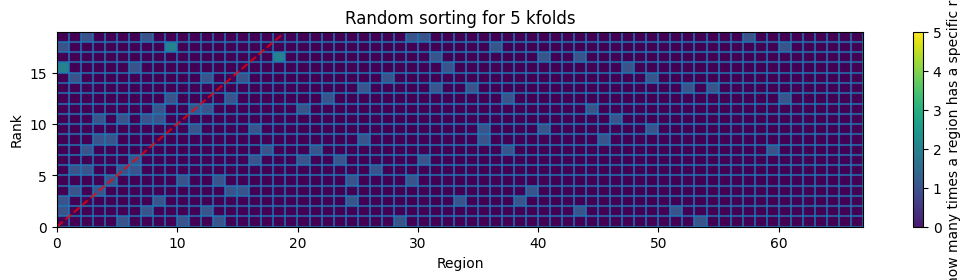

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from matplotlib.colors import ListedColormap

fino_a = 20
n_foldsSS = 5
random_rankings = np.array([np.random.permutation(np.arange(68)) for __ in range(n_foldsSS)])

rankings_random_sorted, sorted_random_regions =  sort_rank(random_rankings)

rankings_random_sorted = rankings_random_sorted[:,:fino_a]

plt.figure(figsize=(13,3.8*fino_a/30))

binx = np.arange(68)-0.001
biny = np.arange(fino_a)-0.001

mic = matplotlib.colormaps.get_cmap("viridis")
color0 = mic(0.)
other_colors = mic(np.linspace(0.07, 1., 1001))
colors = np.vstack([color0, other_colors])
cmap = ListedColormap(colors)

hist = plt.hist2d(
    rankings_random_sorted.flatten(),
    np.tile(np.arange(fino_a), (n_foldsSS,1)).flatten(),
    bins=(binx, biny),
    cmap=cmap, vmin=0, vmax=len(rankings_random_sorted)  # ensures 6 discrete levels
)

coco = "C0"
plt.vlines(binx,0,fino_a,alpha=0.75,color=coco)
plt.hlines(biny,0,68,alpha=0.75,color=coco)

plt.colorbar(label="how many times a region has a specific rank")
plt.xlabel("Region")
plt.ylabel("Rank")
plt.title(f"Random sorting for {len(rankings_random_sorted)} kfolds")
plt.plot([0,68],[0,68],color="red",linestyle="--",alpha=0.7)

## Multi T-test - on complete Power Spectra

In [11]:
import pingouin as pg


import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

subject_index = 0
region = 33

data_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

sfreq = 250
pvalues=[]
power_MI, power_Rest, Freqs = compute_welch(data_MI,data_Rest)
for region in range(68):
    result = pg.multivariate_ttest(power_MI[:,region,:], power_Rest[:,region,:])
    pvalues.append(float(result.pval.values[0]))
# print(result)


subject_0 trial_78 has wrong shape ((2,))
subject_0 trial_79 has wrong shape ((2,))
subject_0 trial_80 has wrong shape ((2,))
subject_0 trial_81 has wrong shape ((2,))
subject_0 trial_82 has wrong shape ((2,))
subject_0 trial_83 has wrong shape ((2,))
subject_0 trial_84 has wrong shape ((2,))
subject_0 trial_85 has wrong shape ((2,))
subject_0 trial_86 has wrong shape ((2,))
subject_0 trial_87 has wrong shape ((2,))
subject_0 trial_88 has wrong shape ((2,))
subject_0 trial_89 has wrong shape ((2,))
subject_0 trial_90 has wrong shape ((2,))
subject_0 trial_91 has wrong shape ((2,))
subject_0 trial_92 has wrong shape ((2,))
subject_0 trial_93 has wrong shape ((2,))
subject_0 trial_94 has wrong shape ((2,))
subject_0 trial_95 has wrong shape ((2,))
subject_0 trial_78 has wrong shape ((2,))
subject_0 trial_79 has wrong shape ((2,))
subject_0 trial_80 has wrong shape ((2,))
subject_0 trial_81 has wrong shape ((2,))
subject_0 trial_82 has wrong shape ((2,))
subject_0 trial_83 has wrong shape

In [12]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=2
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

import math

round_sig = lambda x, sig=5: 0 if x == 0 else round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)

saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
        dizio[f"Pvalues_{fold+1}"] = []


    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq)

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = val_idx
            pvalues = []


            for region in range(68):
                result = pg.multivariate_ttest(WMI[selected_idx[np.where(selected_idx>=len(WRe))]-len(WRe) ,region,:], 
                                               WRe[selected_idx[np.where(selected_idx<len(WRe))],region,:])
                pvalues.append(float(result.pval.values[0]))
            pvalues=np.array(pvalues)
            regions_selected=pvalues.argsort() # in base a chi ha il pvalue più piccolo
            pvalues = pvalues[pvalues.argsort()]
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple([ int(_) for _ in regions_selected]))
            dizio[f"Pvalues_{fold_idx+1}"].append(tuple([round_sig(float(_),3) for _ in pvalues]))
    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MultiTtest_{DataType}_among_{n_folds}_folds_validation_selected_all_spectra.pkl")

100%|██████████| 20/20 [01:28<00:00,  4.44s/it]


## Multi T-test - on average of 2 bands

In [ ]:
import pingouin as pg


import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

subject_index = 2
region = 33

data_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

sfreq = 250
pvalues=[]
power_MI, power_Rest, Freqs = compute_welch(data_MI,data_Rest, kargs_welch={"fmin":8, "fmax":30})
# for region in range(68):
#     result = pg.multivariate_ttest(power_MI[:,region,:], power_Rest[:,region,:])
#     pvalues.append(float(result.pval.values[0]))
# print(result)


In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
import pingouin as pg

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

import math

round_sig = lambda x, sig=5: 0 if x == 0 else round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)

saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
        dizio[f"Pvalues_{fold+1}"] = []
    dizio[f"ROIs_All_trials"] = []
    dizio[f"Pvalues_All_trials"] = []

    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq)

        mean_alph = np.concatenate((WMI[:,:,np.where(FreqMI<12)].mean(axis=-1),WMI[:,:,np.where(FreqMI>=12)].mean(axis=-1)),axis=-1)
        mean_beta = np.concatenate((WRe[:,:,np.where(FreqMI<12)].mean(axis=-1),WRe[:,:,np.where(FreqMI>=12)].mean(axis=-1)),axis=-1)

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(mean_alph))] + [0 for __ in range(len(mean_beta))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx
            pvalues = []
            
            for region in range(68):
                result = pg.multivariate_ttest(mean_alph[selected_idx[np.where(selected_idx<len(mean_alph))],region,:], 
                                               mean_beta[selected_idx[np.where(selected_idx>=len(mean_alph))]-len(mean_alph),region,:])
                pvalues.append(float(result.pval.values[0]))
            pvalues=np.array(pvalues)
            regions_selected=pvalues.argsort() # in base a chi ha il pvalue più piccolo
            pvalues = pvalues[pvalues.argsort()]
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple([ int(_) for _ in regions_selected]))
            dizio[f"Pvalues_{fold_idx+1}"].append(tuple([round_sig(float(_),3) for _ in pvalues]))



        pvalues = []
        for region in range(68):
            result = pg.multivariate_ttest(mean_alph[:,region,:], mean_beta[:,region,:])
            pvalues.append(float(result.pval.values[0]))
        pvalues=np.array(pvalues)
        regions_selected=pvalues.argsort() # in base a chi ha il pvalue più piccolo
        pvalues = pvalues[pvalues.argsort()]
        dizio[f"ROIs_All_trials"].append(tuple([ int(_) for _ in regions_selected]))
        dizio[f"Pvalues_All_trials"].append(tuple([round_sig(float(_),3) for _ in pvalues]))




    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MultiTtest_on_mean_alpha_beta_{DataType}_among_{n_folds}_folds_training_selected.pkl")

100%|██████████| 20/20 [01:47<00:00,  5.36s/it]


## Cohen's d effect size

### Per subject selection

In [28]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
        dizio[f"Effect_size_fold_{fold+1}"] = []
    dizio[f"ROIs_All_trials"] = []
    dizio[f"Effect_size_All_trials"] = []

    for subject_index in tqdm.tqdm(range(20)):
    

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                            kargs_welch={"fmin":8, "fmax":30},
                                            #starttime=750,
                                            )

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx

            regions_selected, effect_sizes = select_regions_Cohen_effect_size(wpsdMI=WMI[selected_idx[np.where(selected_idx>=len(WRe))]-len(WRe)], 
                                                            wpsdRest=WRe[selected_idx[np.where(selected_idx<len(WRe))]], 
                                                            important_regions=[], nbest_regions=quanteroi)
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple(regions_selected))
            dizio[f"Effect_size_fold_{fold_idx+1}"].append(tuple(effect_sizes))
        
        ################## All_trials selection, no fold ##################
        regions_selected, effect_sizes = select_regions_Cohen_effect_size(wpsdMI=WMI, 
                                                            wpsdRest=WRe, 
                                                            important_regions=[], nbest_regions=quanteroi)
        dizio[f"ROIs_All_trials"].append(tuple(regions_selected))
        dizio[f"Effect_size_All_trials"].append(tuple(effect_sizes))
         # attenzione qusto è diverso da quello che uso nei codici di addesteamento! 

        
    pandadizio = pd.DataFrame.from_dict(dizio)
    pandadizio.to_pickle(filepath+f"_Cohen_effect_size_{DataType}_among_{n_folds}_folds_training_selected_freq_8_30.pkl")#_startingFrom3s.pkl")




100%|██████████| 20/20 [01:26<00:00,  4.32s/it]


IndexError: index 1 is out of bounds for axis 0 with size 1

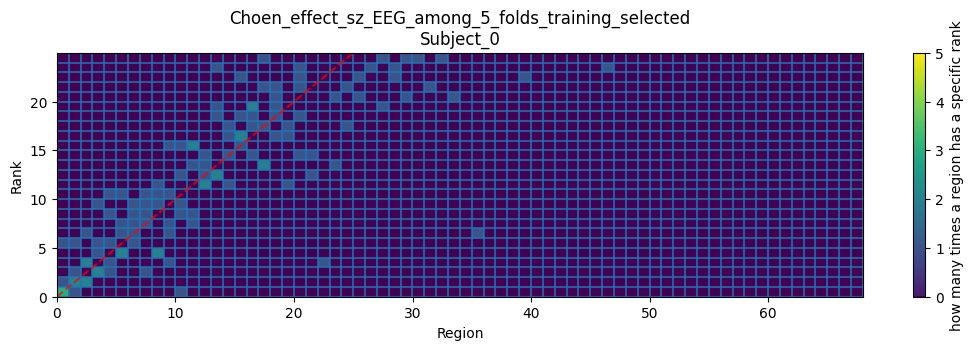

In [20]:
for subject_idx in range(5):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
    "Selected_regions_Cohen_effect_size_EEG_among_5_folds_training_selected_freq_8_30.pkl",
                                subject=subject_idx, num_best_selected=25, plot_sorted=True, 
                                figtitle=f"Choen_effect_sz_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                )


### verify 3s vs 5s

In [29]:
import pandas as pd
filepath = "../Results/RegionSelection/Selected_regions"
DataType = "EEG"; n_folds = 5
select_5s = pd.read_pickle(filepath+f"_Cohen_effect_size_{DataType}_among_{n_folds}_folds_training_selected_freq_8_30.pkl")
select_3s = pd.read_pickle(filepath+f"_Cohen_effect_size_{DataType}_among_{n_folds}_folds_training_selected_freq_8_30_starting_From_3s.pkl")

In [72]:
import numpy as np
import pandas as pd

folds = [f"ROIs_fold_{i}" for i in range(1, 6)]
n_rois = 68
n_subjects = len(select_5s)

# Output: subjects × 68 ROIs
avg_position_diff = np.zeros((n_subjects, n_rois))

for subj in range(n_subjects):
    diffs = []

    for fold in folds:
        list1 = select_3s.loc[subj, fold]
        list2 = select_5s.loc[subj, fold]

        # Compute position of each ROI (1..68)
        pos1 = {roi: idx for idx, roi in enumerate(list1)}
        pos2 = {roi: idx for idx, roi in enumerate(list2)}

        # Difference of positions for all ROIs
        diff = np.array([np.abs((pos1[r] - pos2[r])*(68-pos1[r])/34*(68-pos2[r])/34) for r in range(n_rois)])
        diffs.append(diff)

    # Average across folds
    avg_position_diff[subj] = np.mean(diffs, axis=0)

# Convert to DataFrame (optional)
avg_df = pd.DataFrame(
    avg_position_diff,
    columns=[f"ROI_{i}" for i in range(1, n_rois + 1)]
)

In [73]:
avg_df.mean(axis=1)


0     16.771606
1      6.130674
2      8.033223
3     12.154605
4     11.303211
5      6.192693
6     11.473199
7      8.410075
8     20.809699
9     12.970736
10     7.772975
11    16.428119
12     6.863327
13    11.817413
14     9.877870
15     9.882882
16     8.277132
17    13.757272
18     7.580312
19     7.026689
dtype: float64

In [33]:
select_3s

,Subject,ROIs_fold_1,Effect_size_fold_1,ROIs_fold_2,Effect_size_fold_2,ROIs_fold_3,Effect_size_fold_3,ROIs_fold_4,Effect_size_fold_4,ROIs_fold_5,Effect_size_fold_5,ROIs_All_trials,Effect_size_All_trials
0,0,"(32, 45, 48, 59, 33, 49, 51, 46, 44, 63, 23, 1...","(1.369846226584929, 1.2127215306071768, 1.1680...","(32, 45, 48, 44, 49, 33, 46, 27, 23, 15, 51, 4...","(1.304417396860337, 1.0848651843380064, 1.0833...","(45, 32, 49, 33, 51, 46, 44, 59, 63, 48, 23, 4...","(1.3349776236698092, 1.2643136202329166, 1.224...","(32, 45, 44, 49, 48, 46, 63, 23, 33, 17, 35, 1...","(1.247257642910836, 1.246226863560037, 1.08305...","(33, 32, 45, 49, 48, 44, 14, 59, 63, 51, 15, 4...","(1.2039749672250473, 1.2020655091445962, 1.193...","(32, 45, 49, 33, 48, 44, 46, 51, 63, 59, 23, 1...","(1.253510135459978, 1.2102929032293388, 1.1216..."
1,1,"(43, 59, 23, 7, 67, 61, 20, 27, 1, 32, 51, 26,...","(1.0890605787893894, 0.894907351449597, 0.8925...","(1, 43, 67, 61, 31, 23, 59, 7, 19, 51, 17, 42,...","(1.140401112276184, 0.9791818273332868, 0.9481...","(43, 59, 7, 67, 61, 23, 1, 51, 31, 42, 19, 26,...","(1.0836182733873398, 0.9492763650510093, 0.908...","(59, 43, 23, 1, 67, 61, 7, 51, 15, 31, 30, 20,...","(0.990597826369673, 0.9779673519056906, 0.9268...","(23, 7, 43, 59, 67, 61, 31, 51, 1, 30, 0, 42, ...","(1.067942226132348, 1.008709583679827, 1.00340...","(43, 59, 23, 67, 7, 61, 1, 31, 51, 42, 30, 19,...","(1.0249219621075485, 0.9421833106129563, 0.930..."
2,2,"(50, 32, 14, 44, 33, 4, 48, 47, 58, 62, 46, 59...","(1.8745863484229222, 1.8291022394462828, 1.693...","(50, 14, 32, 33, 44, 4, 48, 47, 62, 58, 46, 45...","(1.9785416154965214, 1.821505720362925, 1.8138...","(32, 50, 14, 44, 33, 48, 58, 4, 47, 62, 46, 45...","(1.8465688110372507, 1.8214540663338978, 1.739...","(50, 32, 14, 44, 33, 48, 4, 47, 58, 62, 46, 45...","(1.8630847754563307, 1.8565010599224583, 1.756...","(32, 14, 50, 33, 44, 48, 4, 47, 46, 45, 62, 58...","(1.91496891213288, 1.764756796926345, 1.692196...","(50, 32, 14, 44, 33, 48, 4, 47, 58, 62, 46, 45...","(1.8377477107632003, 1.8307961786990699, 1.751..."
3,3,"(7, 22, 15, 51, 23, 56, 20, 48, 3, 66, 59, 41,...","(0.8759220729073511, 0.7444406268580183, 0.725...","(7, 41, 51, 48, 15, 62, 22, 0, 23, 59, 56, 52,...","(0.8808831916976507, 0.8467073409268726, 0.800...","(7, 15, 59, 22, 51, 41, 66, 48, 23, 43, 14, 3,...","(0.890855446137651, 0.8197591351186931, 0.8017...","(7, 22, 15, 51, 3, 48, 32, 56, 23, 41, 52, 54,...","(0.8071813147319408, 0.7973235594160016, 0.773...","(15, 22, 51, 7, 48, 56, 41, 23, 14, 43, 59, 8,...","(0.8498121673813349, 0.8162971792417202, 0.791...","(7, 15, 22, 51, 48, 41, 59, 56, 23, 3, 66, 43,...","(0.8197250998937979, 0.7917662881318532, 0.756..."
4,4,"(16, 30, 12, 34, 48, 26, 7, 0, 28, 42, 55, 62,...","(1.012168270840584, 0.9199638076185492, 0.8772...","(16, 30, 12, 34, 2, 48, 28, 26, 3, 31, 1, 11, ...","(1.0289331040137433, 0.9826860446027488, 0.950...","(16, 30, 12, 7, 26, 0, 34, 2, 28, 18, 55, 32, ...","(1.0890644789744954, 0.9406276043986482, 0.893...","(16, 30, 12, 26, 34, 48, 2, 3, 55, 28, 7, 46, ...","(1.0399759488129183, 1.0017471594757592, 0.925...","(16, 30, 12, 28, 8, 34, 2, 29, 26, 3, 53, 65, ...","(1.0277114731740942, 1.0132631960858751, 0.982...","(16, 30, 12, 34, 26, 28, 2, 3, 7, 29, 8, 48, 0...","(1.0125712731076575, 0.9720477161284052, 0.924..."
5,5,"(17, 20, 43, 4, 62, 23, 22, 42, 51, 12, 27, 15...","(1.5065700618886015, 1.4517743125163471, 1.385...","(20, 4, 43, 17, 12, 62, 23, 63, 22, 15, 58, 16...","(1.6050067146089784, 1.3791139378645236, 1.336...","(20, 4, 17, 62, 43, 23, 12, 22, 47, 51, 15, 42...","(1.5544949555997118, 1.4996417645699827, 1.397...","(20, 17, 4, 43, 62, 47, 23, 42, 22, 12, 15, 27...","(1.6512296542931342, 1.4288997306212972, 1.403...","(12, 20, 17, 27, 4, 43, 22, 15, 16, 6, 23, 62,...","(1.4870220831674381, 1.4816783249577496, 1.470...","(20, 17, 4, 43, 62, 12, 22, 23, 15, 27, 42, 51...","(1.5406327033166924, 1.4267943225253052, 1.350..."
6,6,"(44, 32, 48, 47, 4, 58, 

### Global selection - One selection for ALL subjects

[14, 32, 42, 43, 44, 46, 47, 48, 51, 62] 10


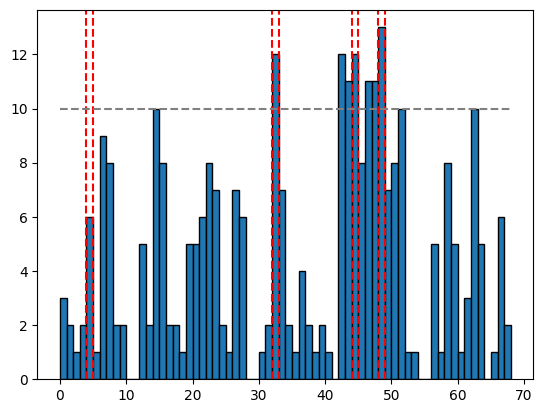

In [9]:
#RIVEDI TUTTO CHE ERO STANCO E FORSE HO FATTO UN CASINO (perche mi esce che )


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
DataType = "MEG"
filepath = "../Results/RegionSelection/Selected_regions"
selection_method = "Cohen_effect_size" # "Cohen_effect_size", "MyCriteria"
fino_a = 15


soglias_cohen = {"EEG":{10:6,15:8},"MEG":{10:8,15:10}}
soglias_mycriteria = {"EEG":{10:6,15:8},"MEG":{10:7,15:9}}
soglias = soglias_cohen if selection_method=="Cohen_effect_size" else soglias_mycriteria if selection_method=="MyCriteria" else None

soglia = soglias[DataType][fino_a] # 7 per MEG,finoa10 - 10 per MEG,finoa15 -  6 per EEG,finoa10 - 8 per EEG,finoa15

regioni_selected = pd.read_pickle(filepath+f"_{selection_method}_{DataType}_among_5_folds_training_selected_freq_8_30.pkl")["ROIs_All_trials"].to_numpy()


regioni_selected = np.array(regioni_selected.tolist())
"""how_many_times = {}
for regione in range(68):
    how_many_times[regione] = 0
for subject in range(20):
    for migiori_regioni in range(fino_a):
        regione_ora = regioni_selected[subject,migiori_regioni]
        how_many_times[regione_ora] +=  1 
"""

mean_position = {}
for regione in range(68):
    mean_position[regione] = 0
for subject in range(20):
    for position_selected in range(68):
        regione_ora = regioni_selected[subject,position_selected]

        mean_position[regione_ora] +=  position_selected # if position_selected < fino_a else (fino_a+68)/2
for key in mean_position:
    mean_position[key] = mean_position[key]/20
    
     
counts,bins,graphics = plt.hist(regioni_selected[:,0:fino_a].flatten(),bins=np.arange(0,69), edgecolor="black")

regioni_finali = [i for i in range(len(counts)) if counts[i] >=  soglia ]

u = plt.ylim()
# evidenzio regioni importanti right
plt.vlines([4,5,32,33,44,45,48,49],0,20,colors="red",linestyles="--" )

plt.ylim(*u)
plt.hlines([soglia],0,68, colors="grey",linestyles="--")

# Quante per ognni soggetto tra le prime "fino_a" sono presenti tra quelle selezionate.
quante_per_soggetto = {}
for i in range(20):
    quante_per_soggetto[i] = 0

for subj_idx, regioni_subject in enumerate(regioni_selected[:,0:fino_a]):
    for regione in regioni_subject:
        if regione in regioni_finali:
            quante_per_soggetto[subj_idx]+=1

print(regioni_finali, len(regioni_finali))


In [19]:
# Quante per ogni soggetto tra le prime "fino_a" sono presenti tra quelle selezionate.
quante_per_soggetto

{0: 4,
 1: 5,
 2: 7,
 3: 8,
 4: 5,
 5: 6,
 6: 7,
 7: 6,
 8: 6,
 9: 6,
 10: 7,
 11: 5,
 12: 6,
 13: 3,
 14: 7,
 15: 7,
 16: 3,
 17: 4,
 18: 3,
 19: 7}

In [11]:
# EEG
print(regioni_finali, "\t", len(regioni_finali))

[14, 20, 32, 33, 44, 46, 48, 50, 58, 62] 	 10


In [20]:
# MEG
print(regioni_finali, "\t", len(regioni_finali))

[14, 32, 42, 43, 44, 46, 47, 48, 51, 62] 	 10


in comune tra EEG - MEG

14, 32, 44, 46, 48, 62

In [30]:
from BCI_Library import plot_brain
import os
color = ["blue"] if DataType=="MEG" else ["green"]
vvs = ['medial','caudal','dorsal']
subjects_dir = 'C:\\Users\\Dell_i5\\mne_data\\MNE-sample-data' + "\\subjects"
os.environ["SUBJECTS_DIR"] = subjects_dir
my_brain=plot_brain(regioni_finali, brain_object_dict={"title":f"{DataType}","hemi": "both", "views":vvs}, colors = color)
my_brain.add_text(0,0.15,f"{DataType}\nGlobal selection\nCohen based\nFirst 10 regions",font_size=10)
my_brain.save_image("../Images/Brain/Region_selection_criteria/"+f"Brain_{DataType}_Global_Selection_Cohen_based.png")



Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot


Text(0.5, 1.0, 'Dimostro che selezionare la media oppure in base al rank è simile')

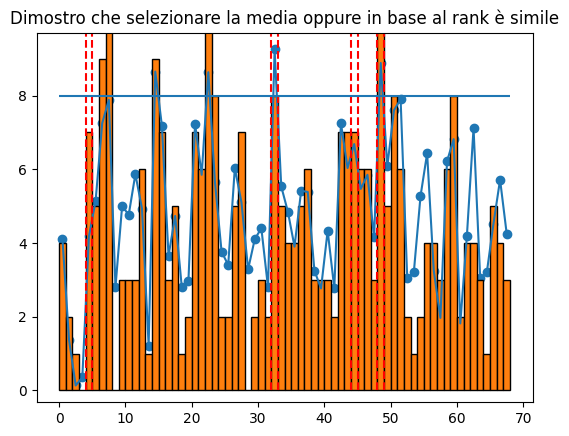

In [25]:
#RIVEDI TUTTO CHE ERO STANCO E FORSE HO FATTO UN CASINO
div = 3
piu = 48

plt.plot([_ + 0.5 for _ in mean_position.keys()],[(-_ +piu)/ div for _ in mean_position.values()])
plt.scatter([_ + 0.5 for _ in mean_position.keys()],[(-_ +piu)/ div for _ in mean_position.values()])
u = plt.ylim()
plt.vlines([4,5,32,33,44,45,48,49],0,20,colors="red",linestyles="--" )

plt.ylim(*u)
plt.hlines([soglia],0,68)
plt.hist(regioni_selected[:,0:fino_a].flatten(),bins=np.arange(0,69), edgecolor="black")
plt.title("Dimostro che selezionare la media oppure in base al rank è simile")

### Verify Frequency bin selection

In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
from BCI_Library import cohens_d_per_columm

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"
cohen_s = {"EEG":[],
           "MEG":[]}
for DataType in ["MEG"]:

    for subject_index in tqdm.tqdm(range(20)):
        cohen_s[DataType].append([])
        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                            kargs_welch={"fmin":8, "fmax":30},
                                            #starttime=750,
                                            )

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            cohen_s[DataType][-1].append([])
            # already computed spectra
            selected_idx = train_idx
            wpsdMI=WMI[selected_idx[np.where(selected_idx>=len(WMI))]-len(WMI)]
            wpsdRest=WRe[selected_idx[np.where(selected_idx<len(WMI))]]
            for roi in range(quanteroi):
                wpsdMI_1ROI =wpsdMI[:,roi,:]
                wpsdRest_1ROI =wpsdRest[:,roi,:]

                cohen_s[DataType][-1][-1].append(cohens_d_per_columm(wpsdMI_1ROI,wpsdRest_1ROI, return_all=True))
    cohen_s[DataType] = np.array(cohen_s[DataType])
# choens_s["EEG"] shape: (sub,fold,roi,freq_bins) (20,5,68,27)



100%|██████████| 20/20 [01:28<00:00,  4.44s/it]


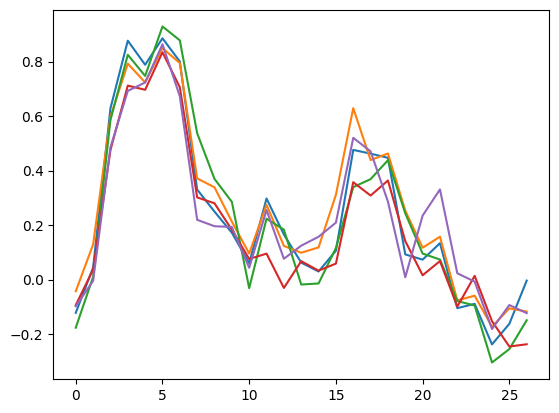

In [29]:
import matplotlib.pyplot as plt
sbj = 0; roi = 11
for i in cohen_s["EEG"][sbj,:,roi]:
    plt.plot(i)

In [13]:
sbj = 0
cohen_s[DataType][sbj].shape

(5, 68, 27)

In [31]:
sbj = 19
ch_sbj_meafold = cohen_s[DataType][sbj].mean(axis=0)
vals = ch_sbj_meafold.max(axis=1)
best_rois = np.argsort(vals)[-20:] [::-1]
np.argmax(ch_sbj_meafold[best_rois],axis=-1)

array([18,  4,  4, 18,  4,  5, 14,  4,  5,  4,  3,  3,  2,  4,  3, 14,  3,
       12,  3,  4])

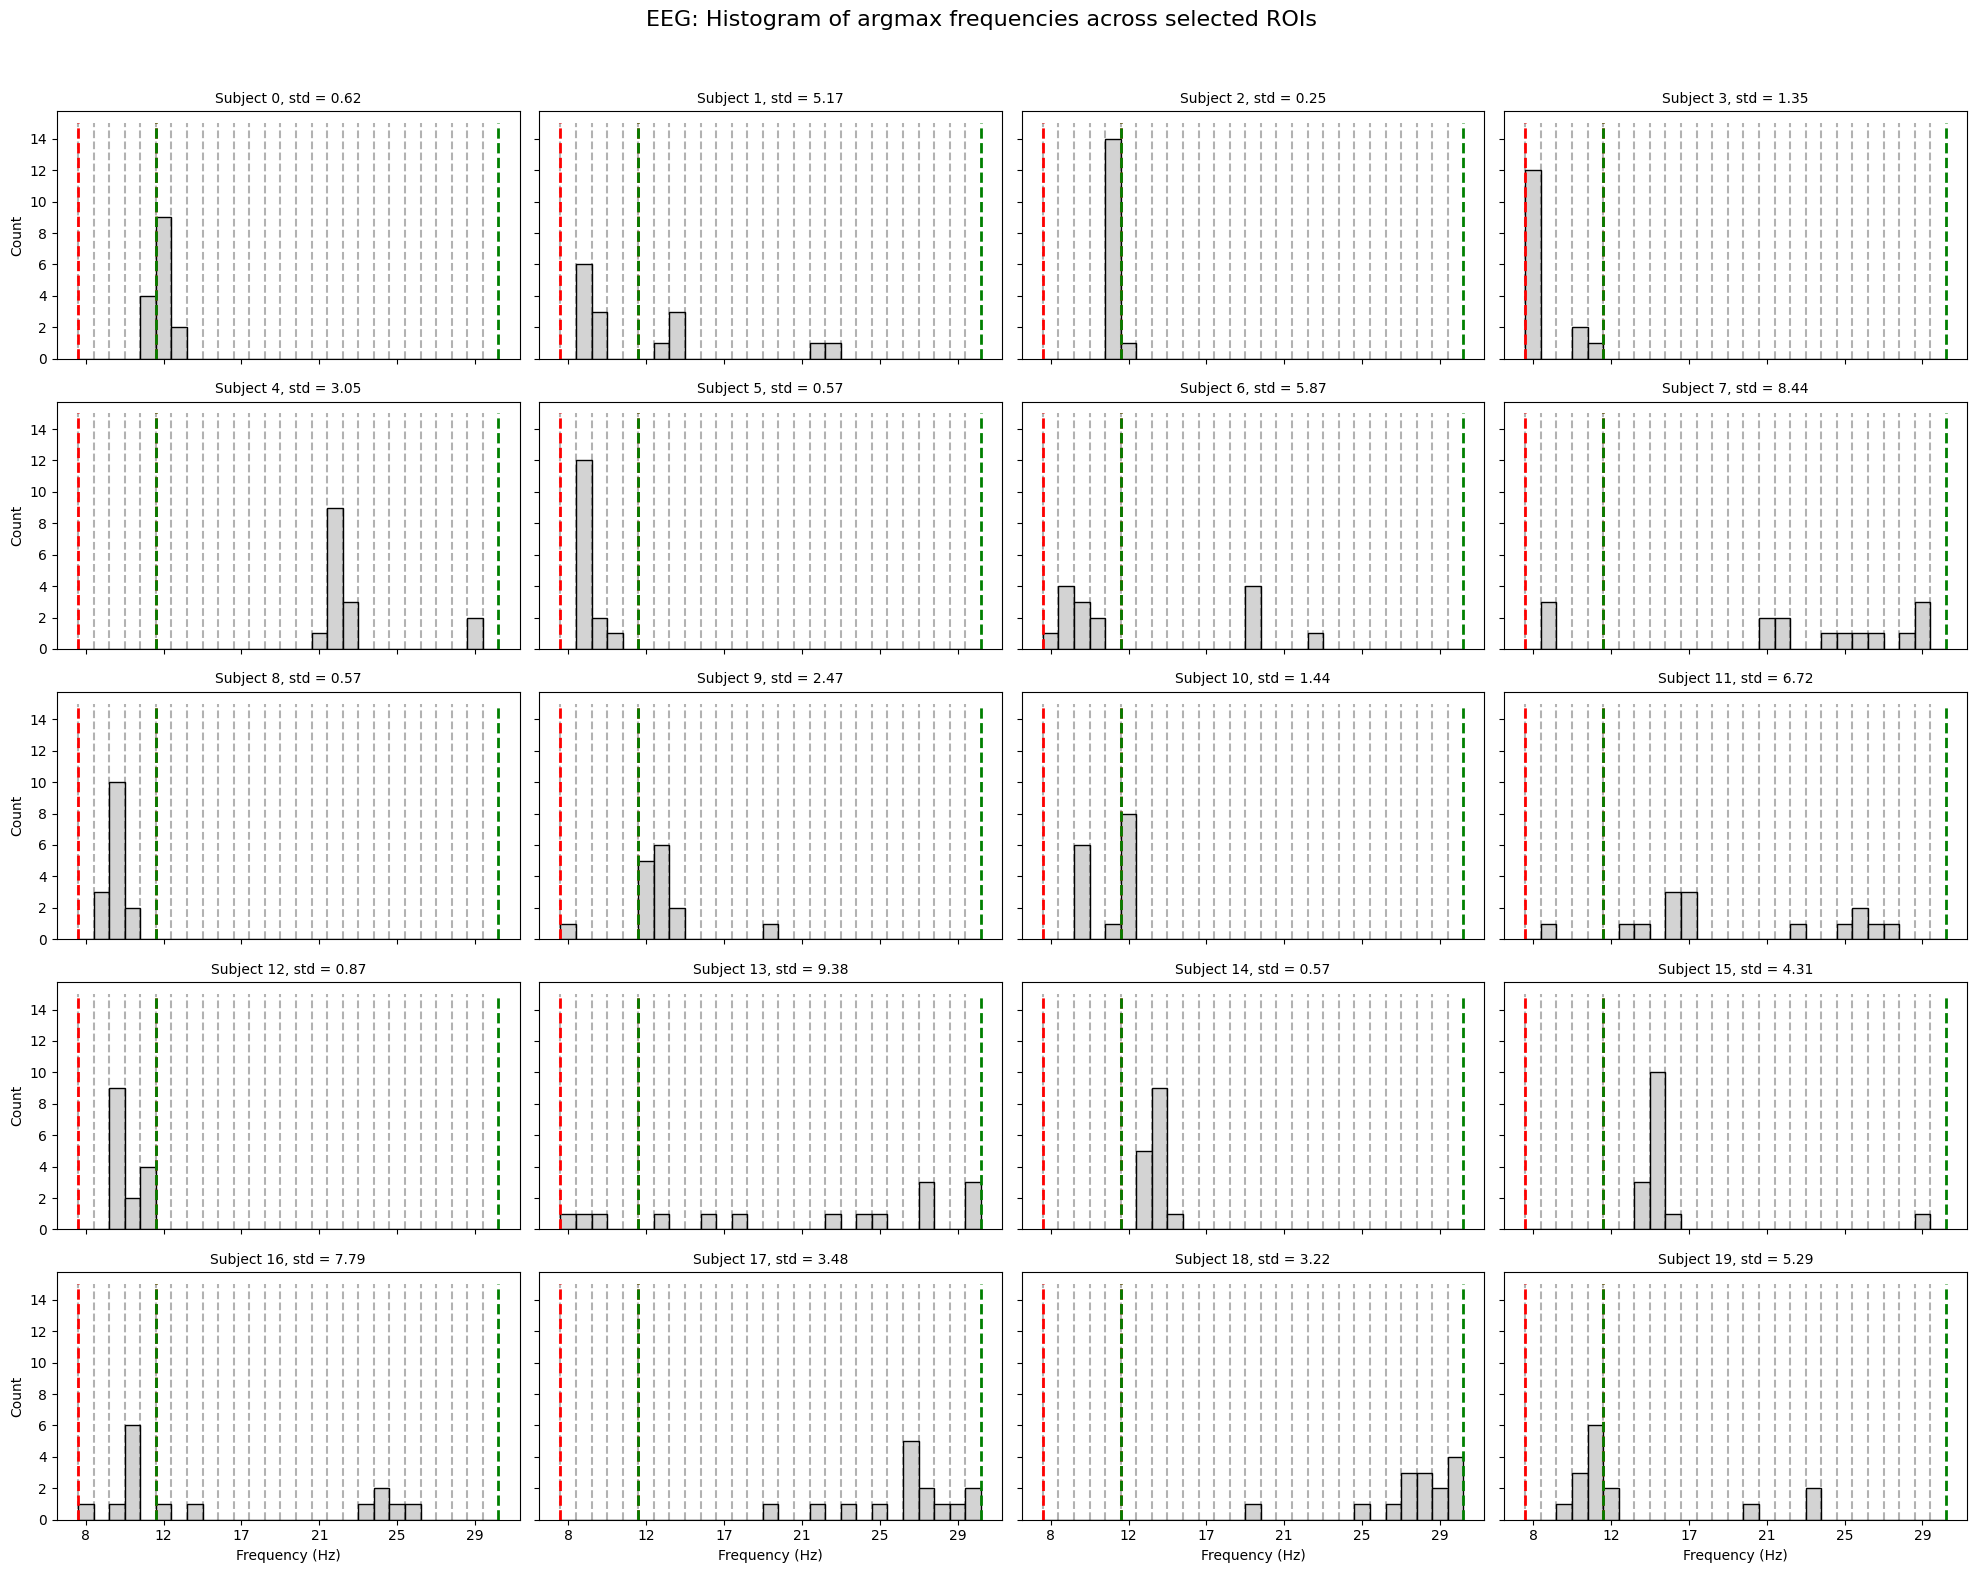

In [68]:
import numpy as np
import matplotlib.pyplot as plt

n_subjects = 20
n_best_rois = 15
DataType = "EEG"   # "MEG"

n_rows, n_cols = 5, 4

# Frequency bands (example)
min_freqs = [8, 12]
max_freqs = [12, 30]
band_colors = ["red", "green"]

tmp = cohen_s[DataType][0].mean(axis=0)
n_freqs = tmp.shape[-1]

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(20, 16),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

for sbj in range(n_subjects):

    ax = axes[sbj]
    ch_sbj_meafold = cohen_s[DataType][sbj].mean(axis=0)
    vals = ch_sbj_meafold.max(axis=1)
    best_rois = np.argsort(vals)[-n_best_rois:][::-1]
    i_freq_max = np.argmax(
        ch_sbj_meafold[best_rois],
        axis=-1
    )


    ax.hist(
        i_freq_max,
        bins=np.arange(n_freqs + 1) - 0.5,
        color="lightgray",
        edgecolor="black"
    )

    # grid lines
    ax.vlines(
        np.arange(n_freqs) - 0.5,
        0,n_best_rois,
        colors="black",
        linestyles="--",
        alpha=0.3
    )

    # FREQUENCY BANDS
    for i, color in enumerate(band_colors):
        start_idx = np.where(FreqMI >= min_freqs[i])[0][0]
        end_idx   = np.where(FreqMI <= max_freqs[i])[0][-1]

        ax.vlines(
            [start_idx - 0.5, end_idx + 0.5],
            0,n_best_rois,
            colors=color,
            linestyles="--",
            linewidth=2
        )


    std_ = np.std(i_freq_max)
    ax.set_title(f"Subject {sbj}, std = {std_:.2f}", fontsize=10)

for ax in axes[-n_cols:]:
    ax.set_xlabel("Frequency (Hz)")
    ticks = [0, 5, 10, 15, 20, 25]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{_:.0f}" for _ in FreqMI[[0, 5, 10, 15, 20, 25]]])


for ax in axes[::n_cols]:
    ax.set_ylabel("Count")



plt.suptitle(
    f"{DataType}: Histogram of argmax frequencies across selected ROIs",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


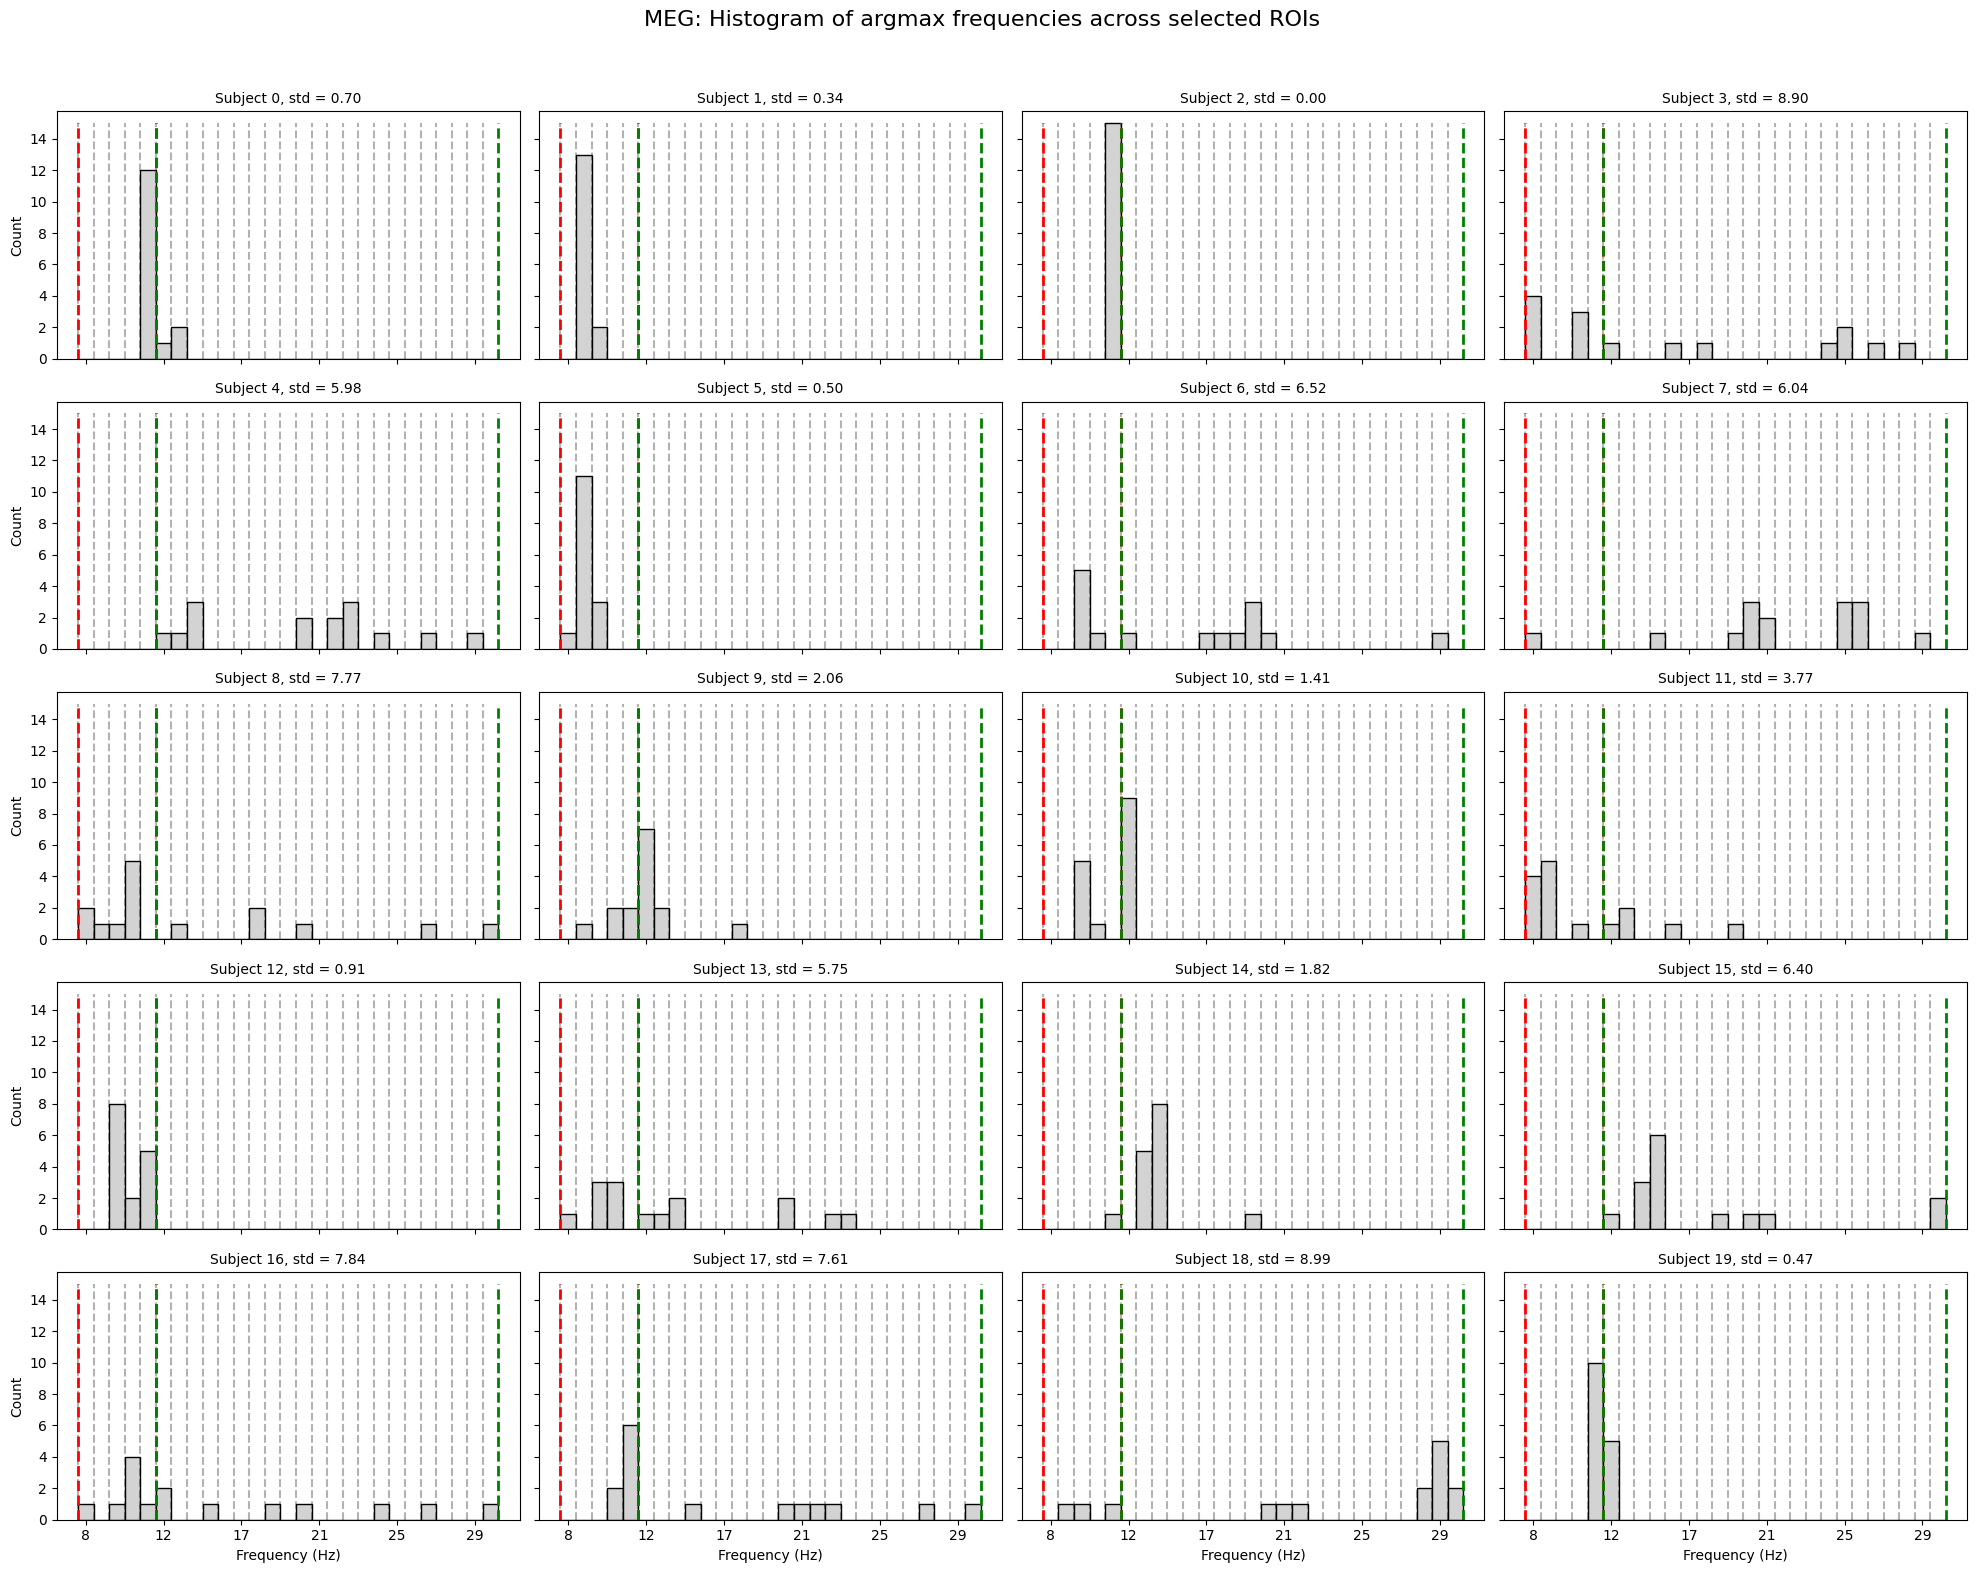

In [5]:
import numpy as np
import matplotlib.pyplot as plt

n_subjects = 20
n_best_rois = 15
DataType = "MEG"   # "MEG"

n_rows, n_cols = 5, 4

# Frequency bands (example)
min_freqs = [8, 12]
max_freqs = [12, 30]
band_colors = ["red", "green"]

tmp = cohen_s[DataType][0].mean(axis=0)
n_freqs = tmp.shape[-1]

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(20, 16),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

for sbj in range(n_subjects):

    ax = axes[sbj]
    ch_sbj_meafold = cohen_s[DataType][sbj].mean(axis=0)
    vals = ch_sbj_meafold.max(axis=1)
    best_rois = np.argsort(vals)[-n_best_rois:][::-1]
    i_freq_max = np.argmax(
        ch_sbj_meafold[best_rois],
        axis=-1
    )


    ax.hist(
        i_freq_max,
        bins=np.arange(n_freqs + 1) - 0.5,
        color="lightgray",
        edgecolor="black"
    )

    # grid lines
    ax.vlines(
        np.arange(n_freqs) - 0.5,
        0,n_best_rois,
        colors="black",
        linestyles="--",
        alpha=0.3
    )

    # FREQUENCY BANDS
    for i, color in enumerate(band_colors):
        start_idx = np.where(FreqMI >= min_freqs[i])[0][0]
        end_idx   = np.where(FreqMI <= max_freqs[i])[0][-1]

        ax.vlines(
            [start_idx - 0.5, end_idx + 0.5],
            0,n_best_rois,
            colors=color,
            linestyles="--",
            linewidth=2
        )


    std_ = np.std(i_freq_max)
    ax.set_title(f"Subject {sbj}, std = {std_:.2f}", fontsize=10)

for ax in axes[-n_cols:]:
    ax.set_xlabel("Frequency (Hz)")
    ticks = [0, 5, 10, 15, 20, 25]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{_:.0f}" for _ in FreqMI[[0, 5, 10, 15, 20, 25]]])


for ax in axes[::n_cols]:
    ax.set_ylabel("Count")



plt.suptitle(
    f"{DataType}: Histogram of argmax frequencies across selected ROIs",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [64]:
[f"{_:.2f}" for _ in FreqMI[[0,5,10,15,20,25]]]

['8.33', '12.50', '16.67', '20.83', '25.00', '29.17']

## MyCriteria2

In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []


    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch_select_regions(data_2_MI, data_2_Rest, sfreq, important_regions=[], select_regions=False,
                                                        kargs_welch={"fmin":8, "fmax":30})

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx

            
            regions_selected = select_regions_MyCriteria2(wpsdMI=WMI[selected_idx[np.where(selected_idx>=len(WMI))]-len(WMI)], 
                                                            wpsdRest=WRe[selected_idx[np.where(selected_idx<len(WMI))]], 
                                                            important_regions=[], nbest_regions=quanteroi)
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple(regions_selected))
    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MyCriteria_2{DataType}_among_{n_folds}_folds_training_selected_freq_8_30.pkl")




100%|██████████| 20/20 [01:24<00:00,  4.22s/it]


In [ ]:
for subject_idx in range(20):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
    "Selected_regions_MyCriteria_2EEG_among_5_folds_training_selected_freq_8_30.pkl",
                                subject=subject_idx, num_best_selected=68, plot_sorted=True, 
                                figtitle=f"MyCriteria_2_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                save_path="../Images/" \
                                f"Hist2d_region_selection/Temp/MyCriteria_2_5_folds_training_selected_startingFrom3s_subject_{subject_idx}.png",
                                )

# Verify selection

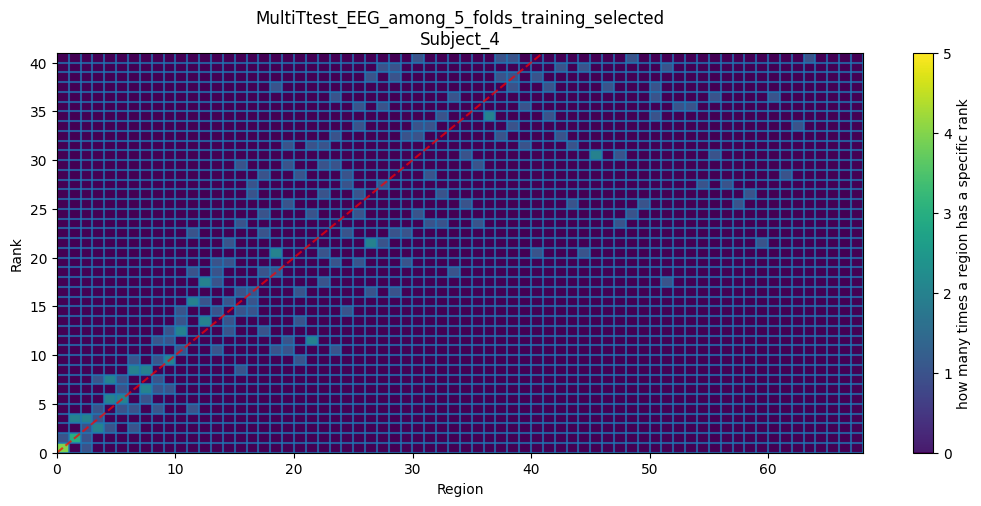

In [ ]:
for subject_idx in range(4,5):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
    "Selected_regions_MultiTtest_EEG_among_5_folds_training_selected.pkl",
                                subject=subject_idx, num_best_selected=41, plot_sorted=True, 
                                figtitle=f"MultiTtest_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                #save_path="../Images/" \
                                #f"Hist2d_region_selection/MultiTtest_EEG_among_5_folds_training_selected_subject_{subject_idx}.png",
                                )


In [ ]:
for subject_index in range(20):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
        "Selected_regions_MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected.pkl",
                                    subject=subject_index, num_best_selected=68, plot_sorted=True, 
                                    figtitle=f"MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected\nSubject_{subject_index}",
                                    #save_path="../Images/" \
                                    #f"Hist2d_region_selection/MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected_subject_{subject_index}.png",
    )
None

In [ ]:
for subject_idx in range(20):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
    "Selected_regions_MyCriteria_EEG_among_5_folds_training_selected_freq_8_30.pkl",
                                subject=subject_idx, num_best_selected=68, plot_sorted=True, 
                                figtitle=f"MyCriteria_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                #save_path="../Images/" \
                                #f"Hist2d_region_selection/MyCriteria_EEG_among_5_folds_training_selected_subject_{subject_idx}_freq_8_30.png"
                                )


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
patti = "../Results/RegionSelection/Selected_regions_MultiTtest_EEG_among_5_folds_training_selected.pkl"
Multi_T_test=pd.read_pickle(patti)
Multi_T_test

# Test